In [1]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../"))
from simulators.CellularAutomaton import CellularAutomaton

# **Examples**

In [40]:
# Exemple de fonctions de pente pour l'influence de la hauteur
def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10 
    

## 1 : No wind no height diff

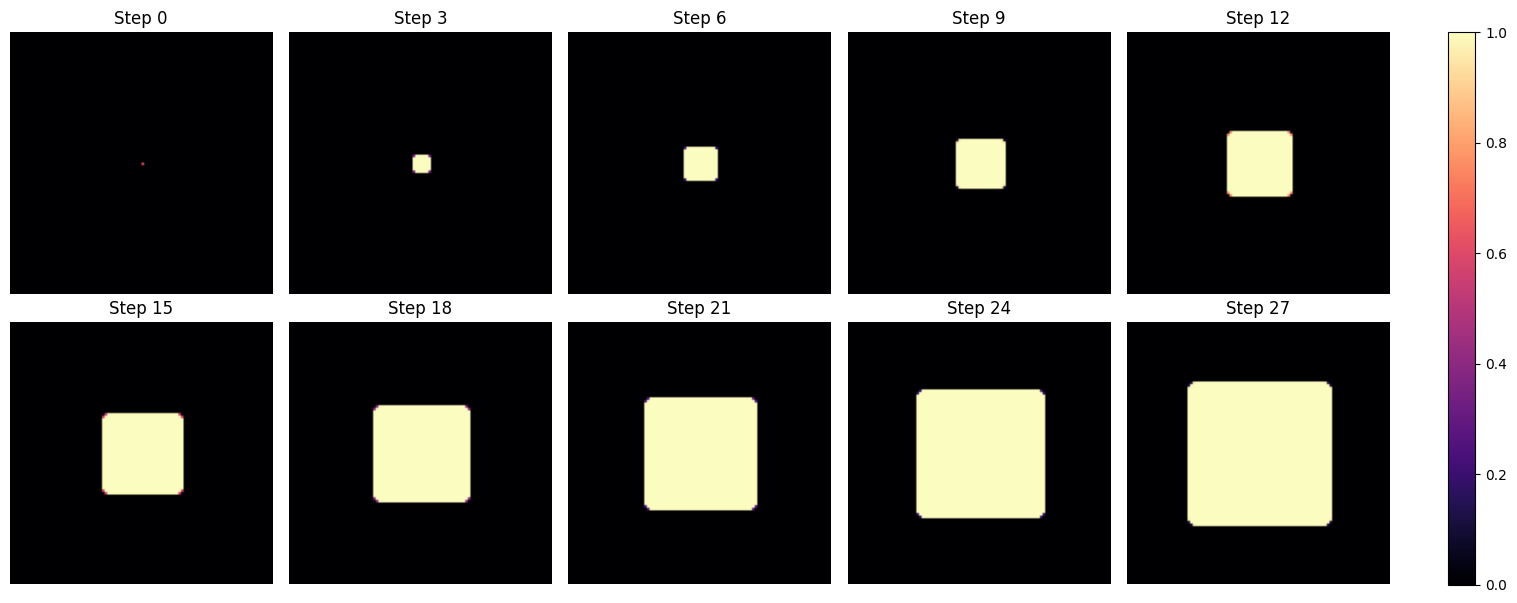

In [51]:
N=100

wind = np.ones((N, N))
heights = np.zeros((N, N))

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0

steps=30
for step in range(steps):
    if step % (steps//10) == 0 and plot_idx < 10:
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show()

Text(0.5, 1.0, 'Propagation du feu au cours du temps')

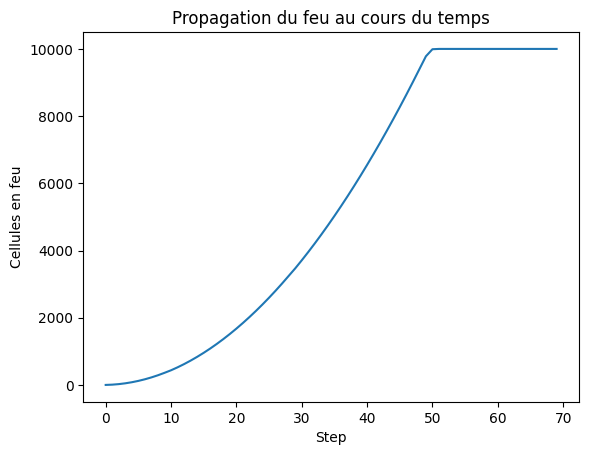

In [53]:
burned_area = []

wind = np.ones((N, N))
heights = np.zeros((N, N))

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])


for step in range(70):
    burned_area.append(np.sum(CA.get_state() > 0.1))
    CA.evolve()

plt.plot(burned_area)
plt.xlabel("Step")
plt.ylabel("Cellules en feu")
plt.title("Propagation du feu au cours du temps")

### 2 : Adding gradient/slope

In [ ]:
# Exemple de fonctions de pente pour l'influence de la hauteur
def height_update(x):
        if x <= 0:
            return np.exp(x)
        else:
            return 1 + np.sqrt(x)/10    

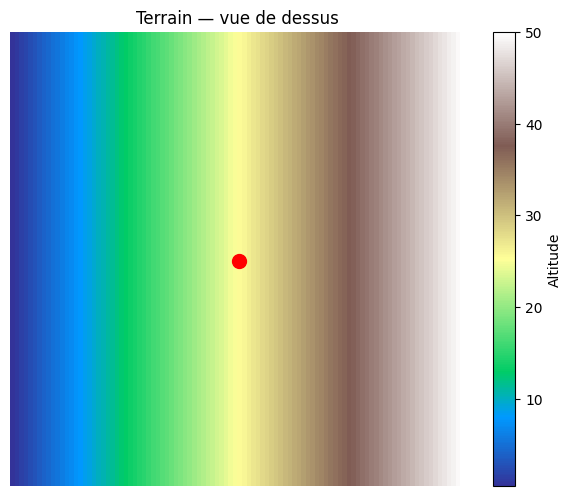

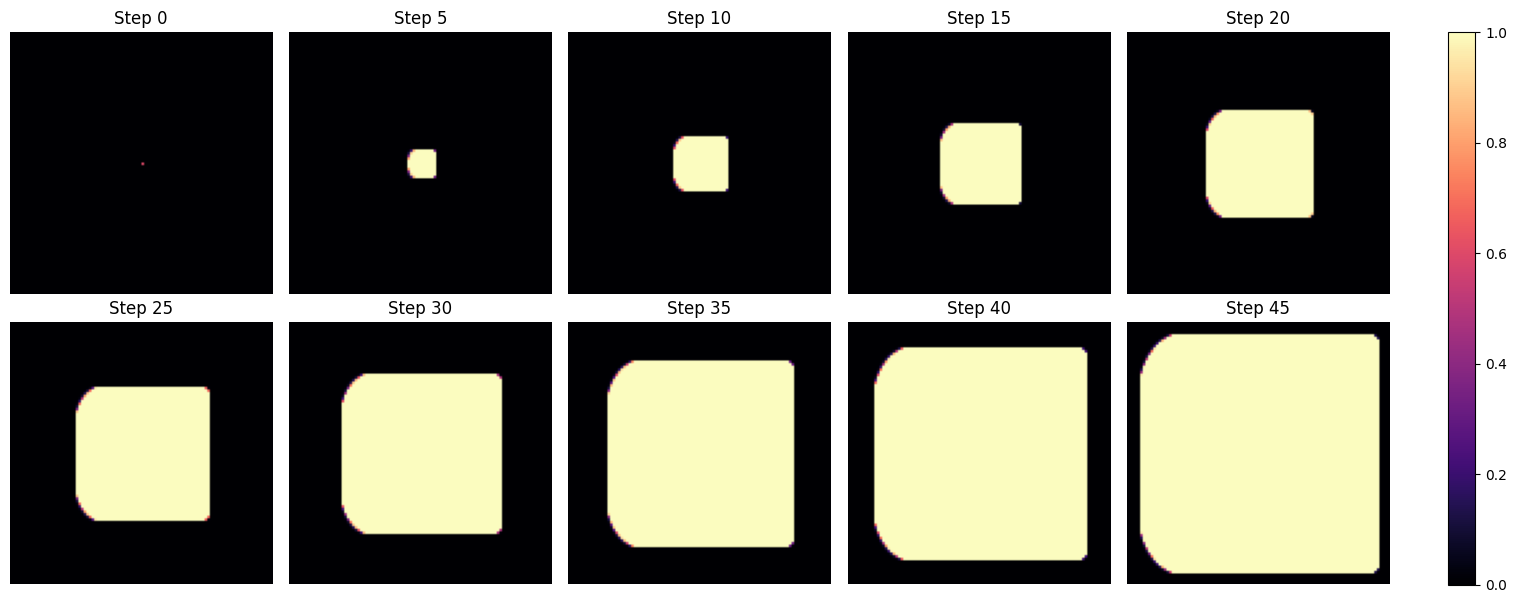

In [39]:
N=100

wind = np.ones((N, N))
# Terrain en pente linéaire : l'altitude augmente de 0.5 par colonne
heights = np.hstack([(k/2)*np.ones((N, 1)) for k in range(1, N+1)])

plt.figure(figsize=(6, 5))
plt.scatter(N//2, N//2, color='red', s=100, zorder=5, label="Foyer initial")
im = plt.imshow(heights, cmap='terrain', origin='upper')
plt.title("Terrain — vue de dessus")
plt.axis('off')
plt.colorbar(im, label="Altitude")
plt.tight_layout()
plt.show()

CA = CellularAutomaton(N, N, wind, heights, height_update)

CA.initialize_ignition([(N//2, N//2)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0


n=50
for step in range(n):
    if step % (n // 10) == 0 and plot_idx < 10:
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    
    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show() 

On devrait s'attendre à voir une propagation du feu accéléré vers la droite et c'est bien le cas. De plus, la propgation est symétrique au bas donc c'est cohérent!

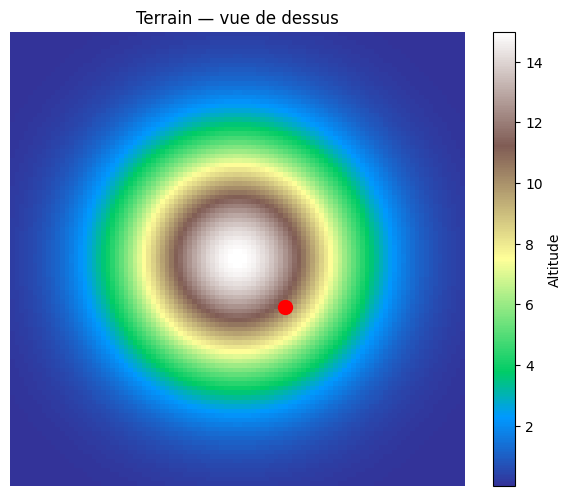

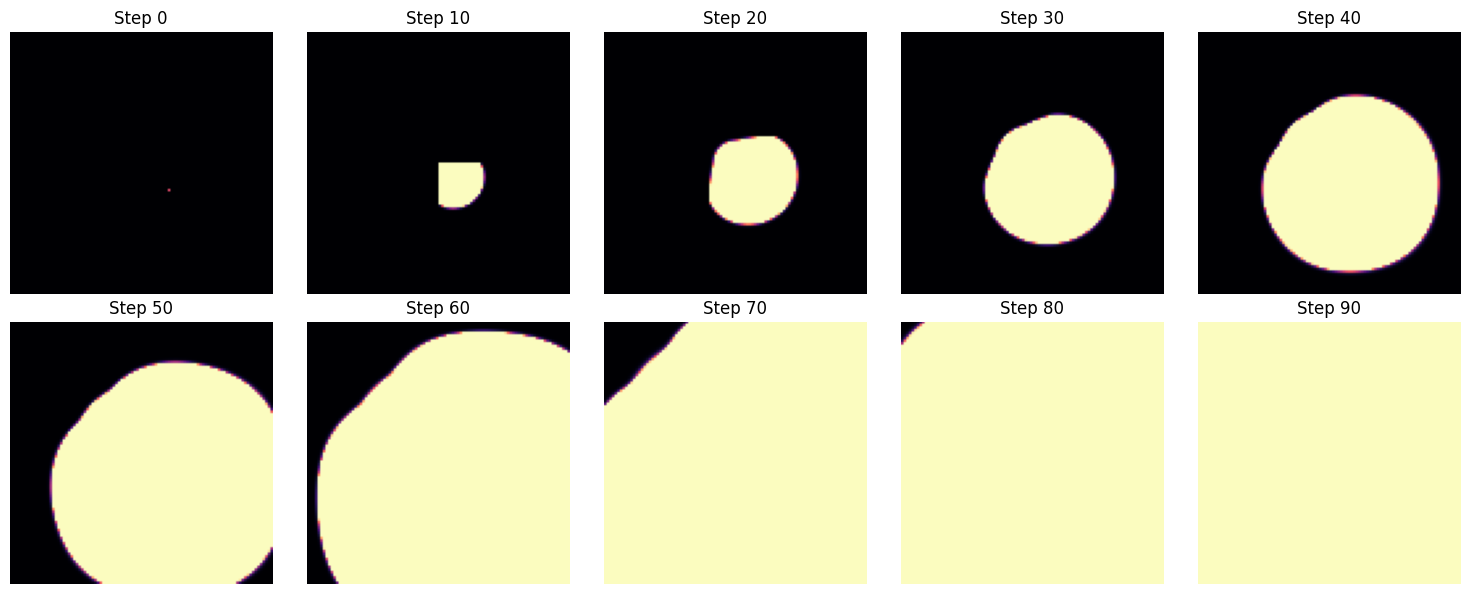

In [32]:
# Ici, le terrain est une montagne centrale
x, y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
heights = 15 * np.exp(-(x**2 + y**2)) # Sommet au centre
plt.figure(figsize=(6, 5))
im = plt.imshow(heights, cmap='terrain', origin='upper')
plt.scatter(60, 60, color='red', s=100, zorder=5, label="Foyer initial")
plt.title("Terrain — vue de dessus")
plt.axis('off')
plt.colorbar(im, label="Altitude")
plt.tight_layout()
plt.show()


# La fonction de pente est plus agressive que l'exponentielle, pour accentuer l'effet de la montagne
def height_update_2(delta_h):
    return np.exp(6.0 * delta_h)
wind = np.ones((100, 100))

CA = CellularAutomaton(100, 100, np.ones((100, 100)), heights, height_update_2)
CA.initialize_ignition([(60, 60)], [0.6]) 


fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0

for step in range(101):
    if step % 10 == 0 and plot_idx < 10:
        current_state = CA.get_state()
        axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1
    CA.evolve()

plt.tight_layout()
plt.show()

On remarque que le résultat est encore une fois très cohérent car le terrain est une montagne Gaussienne centrée. Le feu démarre en bas à droite. On remarque qu'il se propage plus vite dans la montée (step 10). Ensuite, une fois qu'il est arrivé en haut de la colline, il se propage plus lentement car on est dans la descente. Concenrant la patie en bas à droite, une fois qu'il atteint la bas de la colline, il se propage plus vite.

Impact de la fonction phi sur la proagation du feu dans un terrain en pente linéaire

C:\Users\leala\AppData\Local\Temp\ipykernel_21280\1145386652.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


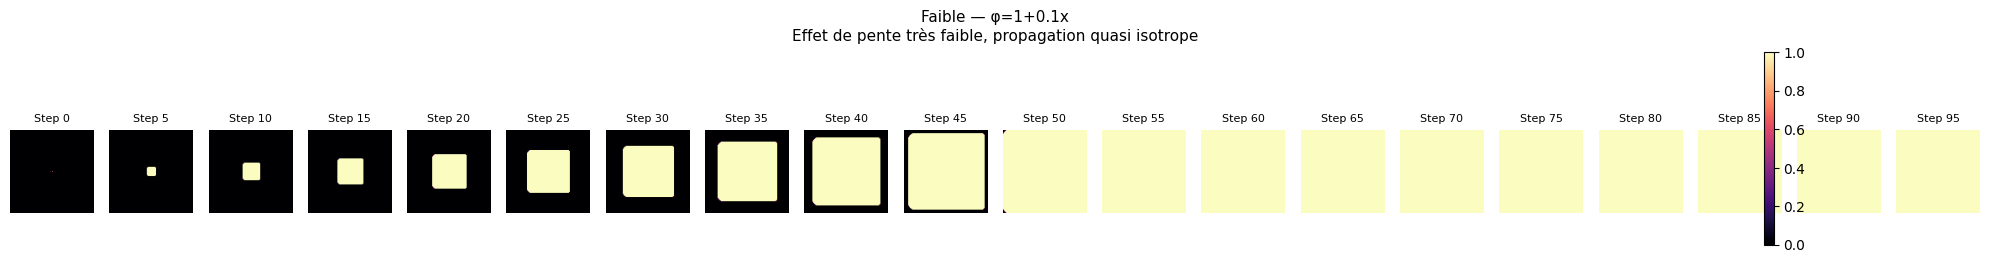

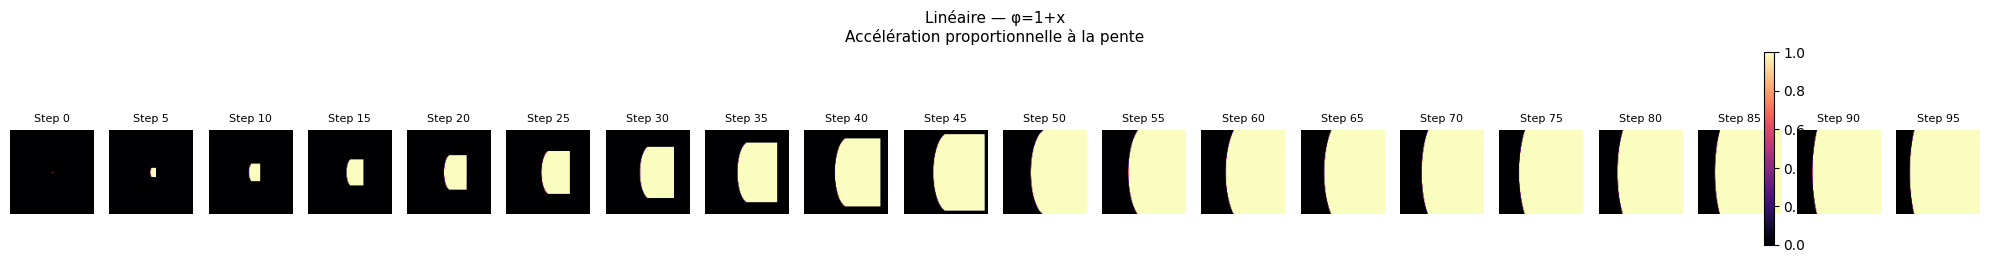

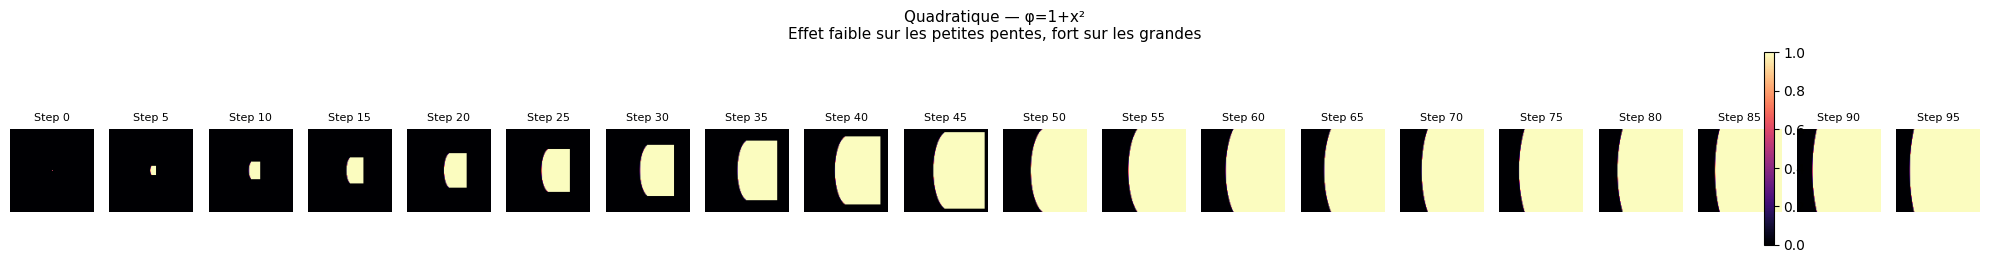

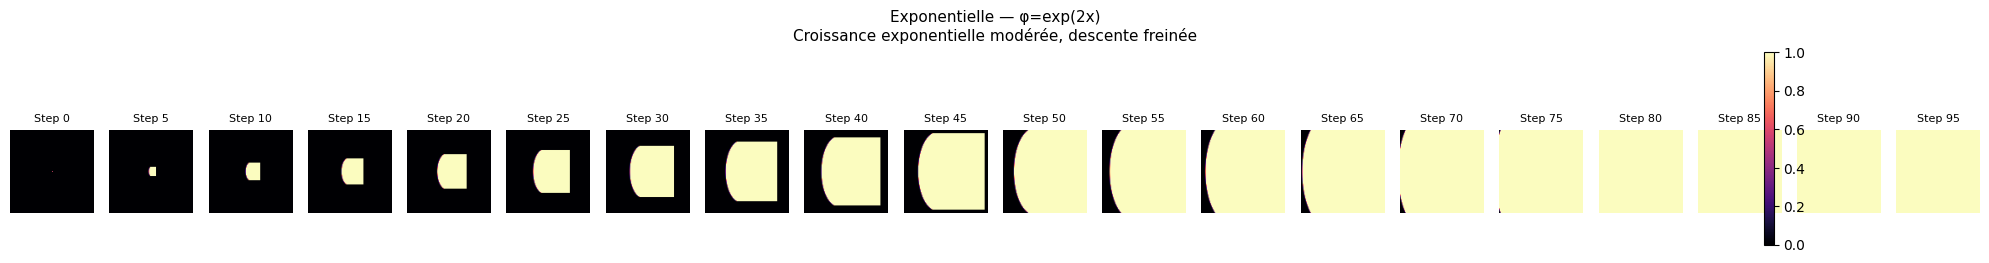

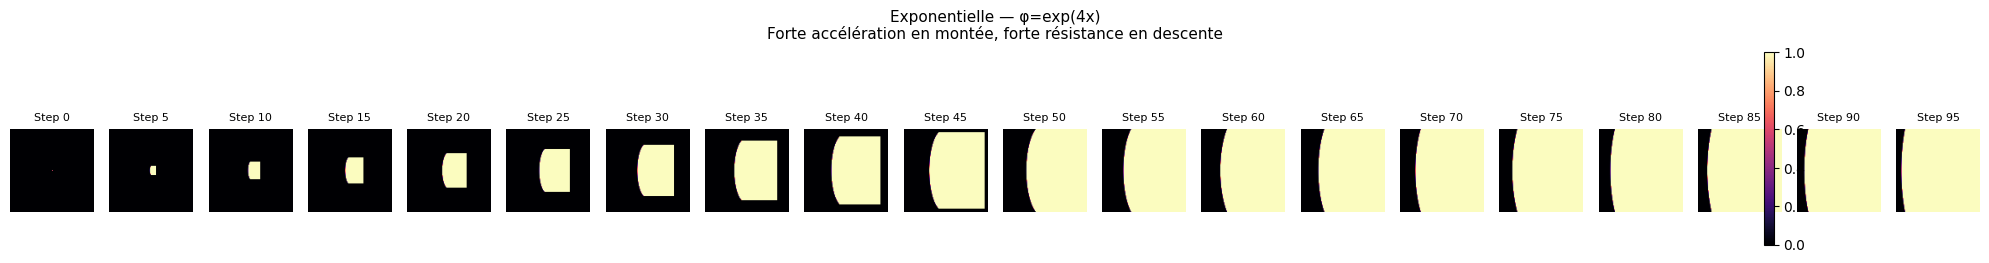

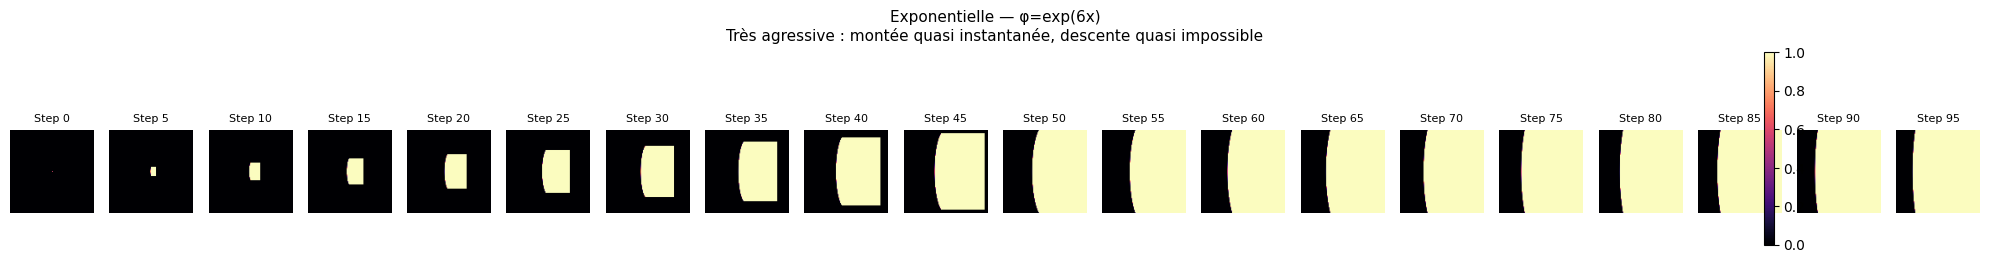

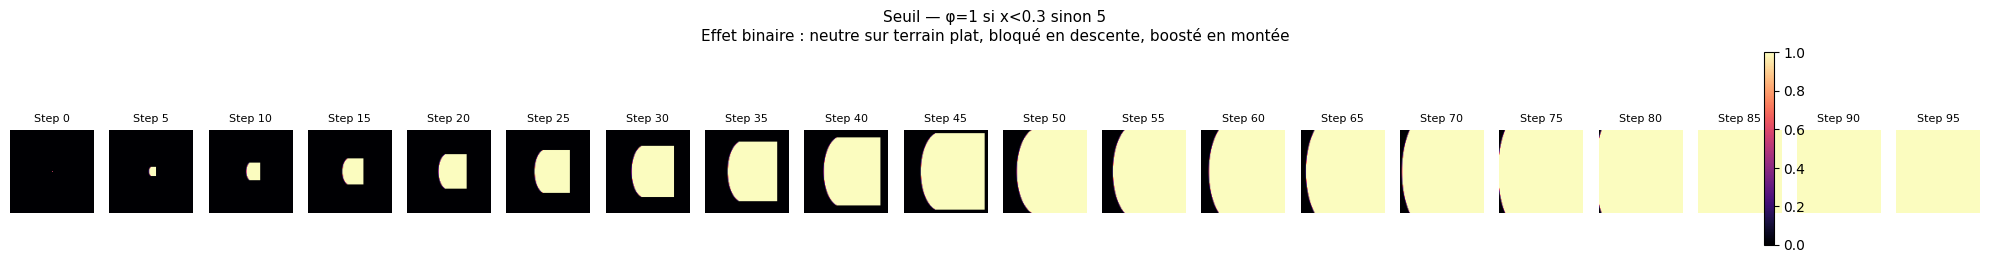

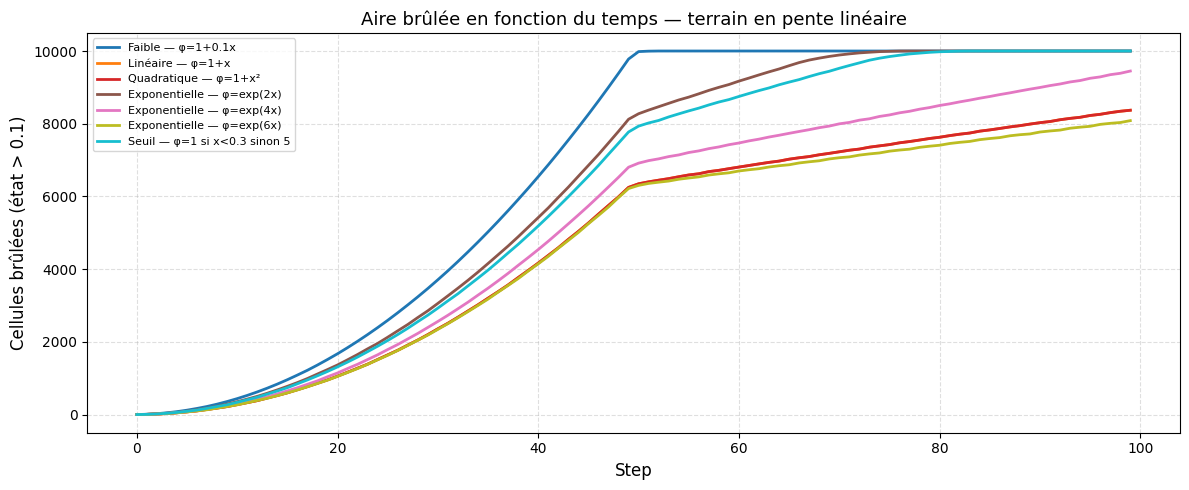

In [43]:
phi_functions = {
    "Faible\nφ=1+0.1x": {
        "fn": lambda x: max(0.01, 1 + 0.1 * x),
        "desc": "Effet de pente très faible, propagation quasi isotrope"
    },
    "Linéaire\nφ=1+x": {
        "fn": lambda x: max(0.01, 1 + x),
        "desc": "Accélération proportionnelle à la pente"
    },
    "Quadratique\nφ=1+x²": {
        "fn": lambda x: max(0.01, 1 + x**2 * np.sign(x)),
        "desc": "Effet faible sur les petites pentes, fort sur les grandes"
    },
    "Exponentielle\nφ=exp(2x)": {
        "fn": lambda x: np.exp(2.0 * x),
        "desc": "Croissance exponentielle modérée, descente freinée"
    },
    "Exponentielle\nφ=exp(4x)": {
        "fn": lambda x: np.exp(4.0 * x),
        "desc": "Forte accélération en montée, forte résistance en descente"
    },
    "Exponentielle\nφ=exp(6x)": {
        "fn": lambda x: np.exp(6.0 * x),
        "desc": "Très agressive : montée quasi instantanée, descente quasi impossible"
    },
    "Seuil\nφ=1 si x<0.3 sinon 5": {
        "fn": lambda x: 0.1 if x < -0.3 else (1.0 if abs(x) <= 0.3 else 5.0),
        "desc": "Effet binaire : neutre sur terrain plat, bloqué en descente, boosté en montée"
    },
}

heights = np.hstack([k * np.ones((100, 1)) for k in range(1, 101)])
wind    = np.ones((100, 100))

n_steps       = 20
step_interval = 5
total_steps   = n_steps * step_interval

burned_histories = {}

for name, entry in phi_functions.items():
    phi  = entry["fn"]
    desc = entry["desc"]

    CA = CellularAutomaton(100, 100, wind, heights, phi)
    CA.initialize_ignition([(50, 50)], [0.6])

    burned    = []
    plot_idx  = 0
    snapshots = []

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

    # Un plot par fonction
    fig, axes = plt.subplots(1, n_steps, figsize=(20, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')

    short_name = name.replace("\n", " — ")
    fig.suptitle(f"{short_name}\n{desc}", fontsize=11, y=1.05)
    plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# Aire brûlée — toutes les fonctions sur un seul graphe
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(phi_functions)))

for (name, burned), color in zip(burned_histories.items(), colors):
    ax.plot(burned, label=name.replace("\n", " — "), linewidth=2, color=color)

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cellules brûlées (état > 0.1)", fontsize=12)
ax.set_title("Aire brûlée en fonction du temps — terrain en pente linéaire", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

Il est donc intéressant de noter que la fonction phi que l'on choisit à un gros impact sur la propagation du feu, même si là encore on remarque que peu importe la fonction, le feu se propage plus vite à droite ce qui est bien le comportement attendu.

Impact de la fonction phi sur la propagation dans un terrain avec une colline au milieu

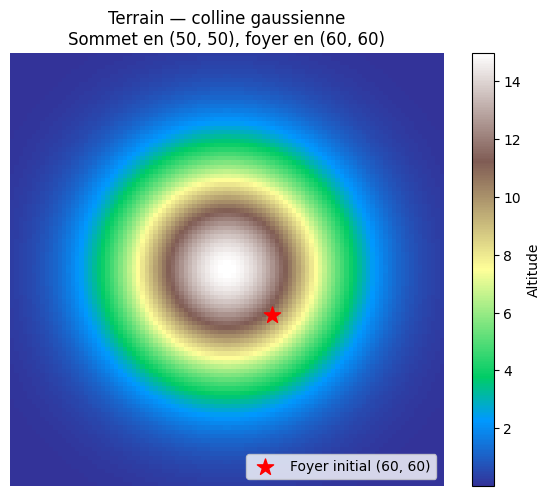

C:\Users\leala\AppData\Local\Temp\ipykernel_21280\1788523054.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


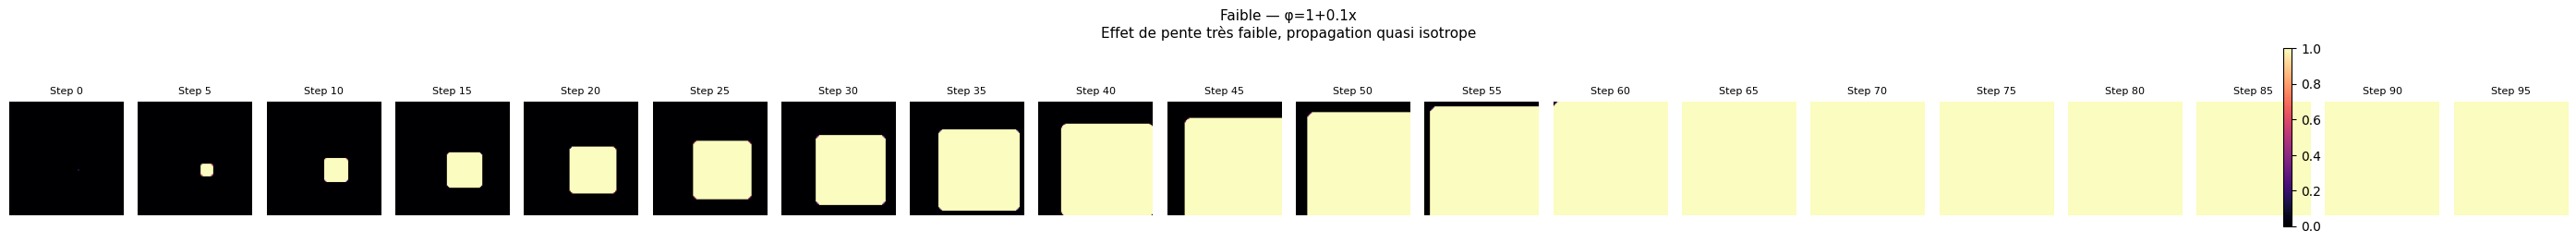

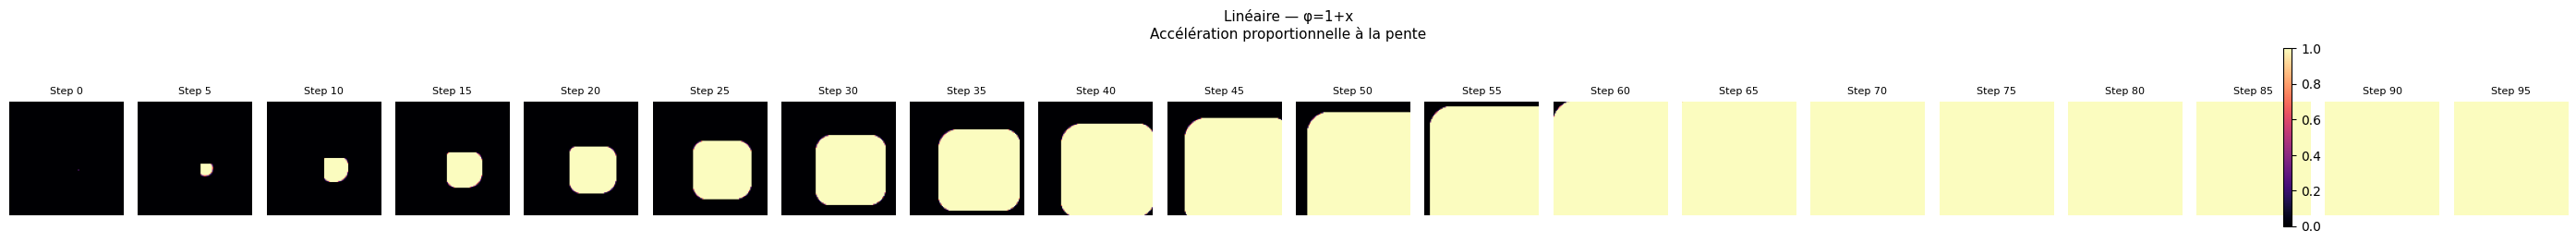

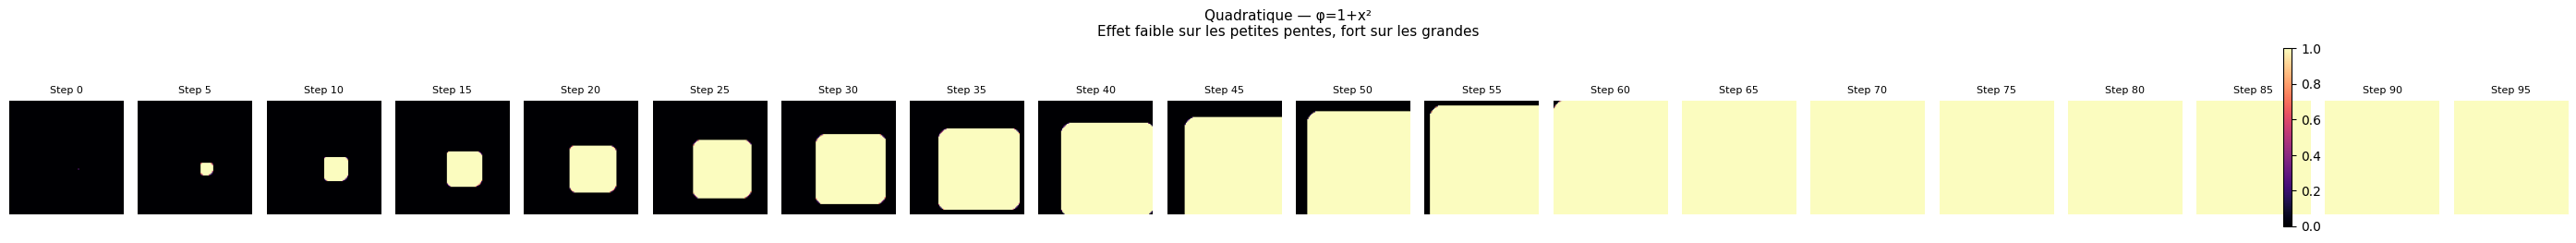

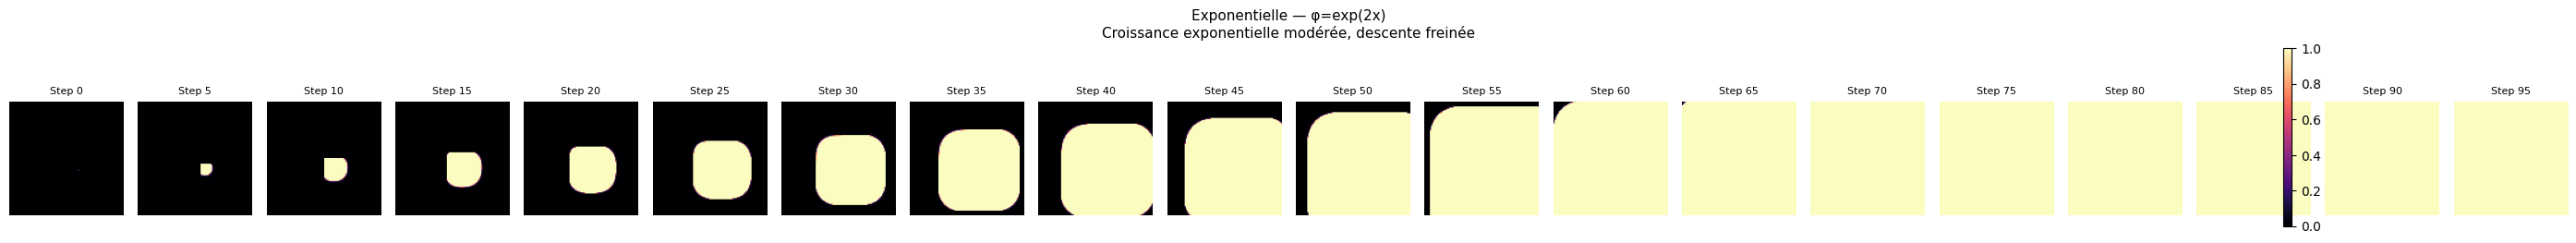

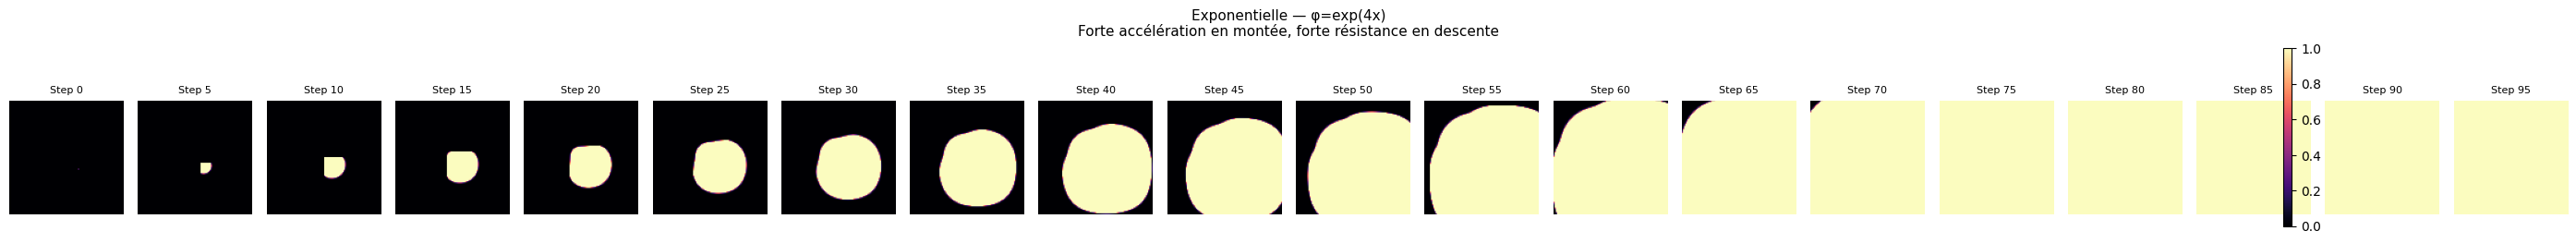

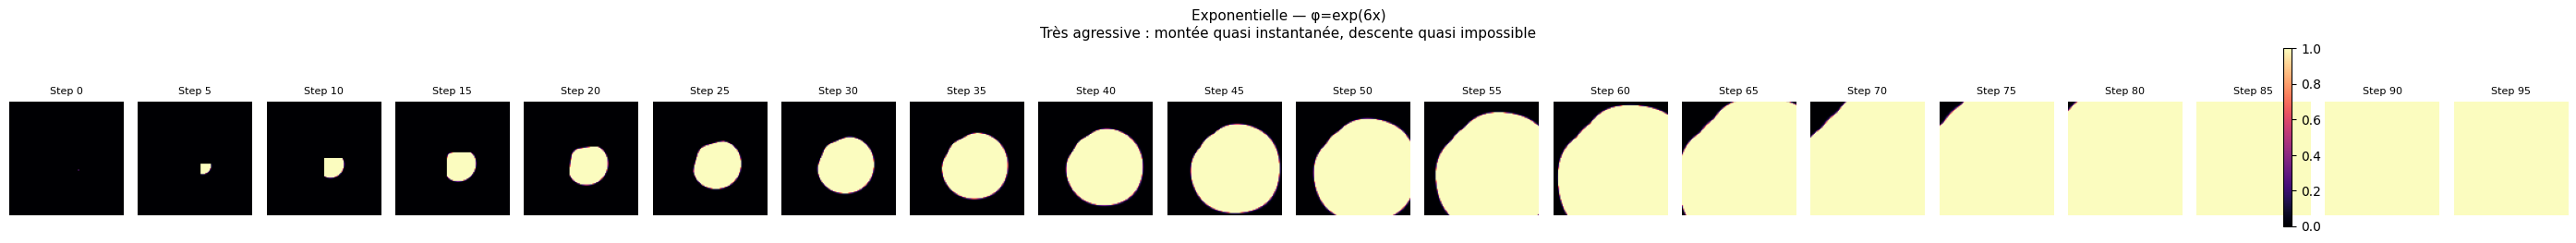

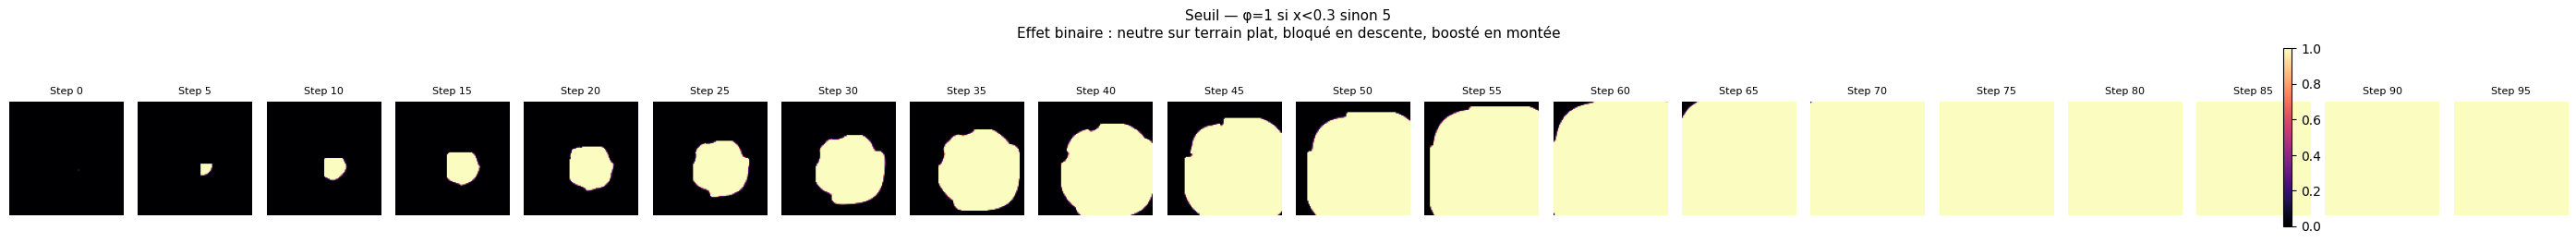

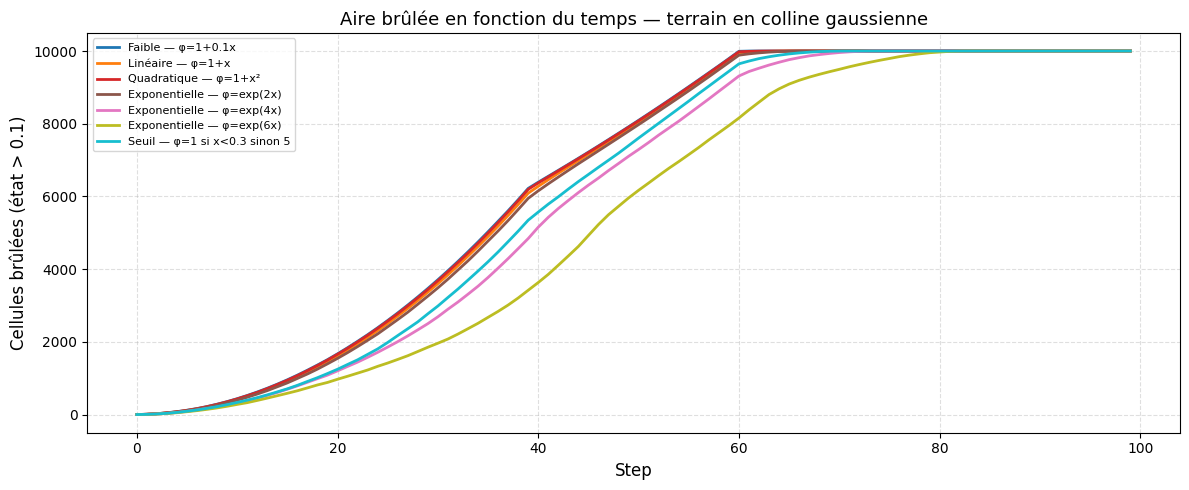

In [54]:
x, y = np.meshgrid(np.linspace(-2, 2, 100), np.linspace(-2, 2, 100))
heights = 15 * np.exp(-(x**2 + y**2))
wind    = np.ones((100, 100))


# Affichage du terrain et du point de départ
plt.figure(figsize=(6, 5))
im_terrain = plt.imshow(heights, cmap='terrain', origin='upper')
plt.scatter(60, 60, color='red', s=150, zorder=5, marker='*', label="Foyer initial (60, 60)")
plt.title("Terrain — colline gaussienne\nSommet en (50, 50), foyer en (60, 60)")
plt.colorbar(im_terrain, label="Altitude")
plt.legend(loc="lower right")
plt.axis('off')
plt.tight_layout()
plt.show()

phi_functions = {
    "Faible\nφ=1+0.1x": {
        "fn": lambda x: max(0.01, 1 + 0.1 * x),
        "desc": "Effet de pente très faible, propagation quasi isotrope"
    },
    "Linéaire\nφ=1+x": {
        "fn": lambda x: max(0.01, 1 + x),
        "desc": "Accélération proportionnelle à la pente"
    },
    "Quadratique\nφ=1+x²": {
        "fn": lambda x: max(0.01, 1 + x**2 * np.sign(x)),
        "desc": "Effet faible sur les petites pentes, fort sur les grandes"
    },
    "Exponentielle\nφ=exp(2x)": {
        "fn": lambda x: np.exp(2.0 * x),
        "desc": "Croissance exponentielle modérée, descente freinée"
    },
    "Exponentielle\nφ=exp(4x)": {
        "fn": lambda x: np.exp(4.0 * x),
        "desc": "Forte accélération en montée, forte résistance en descente"
    },
    "Exponentielle\nφ=exp(6x)": {
        "fn": lambda x: np.exp(6.0 * x),
        "desc": "Très agressive : montée quasi instantanée, descente quasi impossible"
    },
    "Seuil\nφ=1 si x<0.3 sinon 5": {
        "fn": lambda x: 0.1 if x < -0.3 else (1.0 if abs(x) <= 0.3 else 5.0),
        "desc": "Effet binaire : neutre sur terrain plat, bloqué en descente, boosté en montée"
    },
}

n_steps       = 20
step_interval = 5
total_steps   = n_steps * step_interval  # 80 steps

burned_histories = {}

for name, entry in phi_functions.items():
    phi  = entry["fn"]
    desc = entry["desc"]

    CA = CellularAutomaton(100, 100, wind, heights, phi)
    CA.initialize_ignition([(60, 60)], [0.3])

    burned    = []
    plot_idx  = 0
    snapshots = []

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

    # Un plot par fonction
    fig, axes = plt.subplots(1, n_steps, figsize=(28, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')

    short_name = name.replace("\n", " — ")
    fig.suptitle(f"{short_name}\n{desc}", fontsize=11, y=1.05)
    plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# Aire brûlée
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(phi_functions)))

for (name, burned), color in zip(burned_histories.items(), colors):
    short_name = name.replace("\n", " — ")
    ax.plot(burned, linewidth=2, color=color, label=short_name)

ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cellules brûlées (état > 0.1)", fontsize=12)
ax.set_title("Aire brûlée en fonction du temps — terrain en colline gaussienne", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

On observe bien dans la propagation différentes étapes correspondant à la période où le feu monte jusqu'au sommet, puis atteint le sommet et ensuite la propagation se ralentit.

### Impact of the Wind on the fire propagation


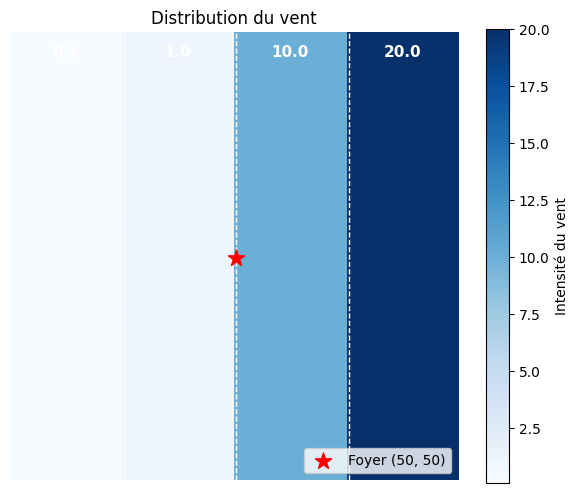

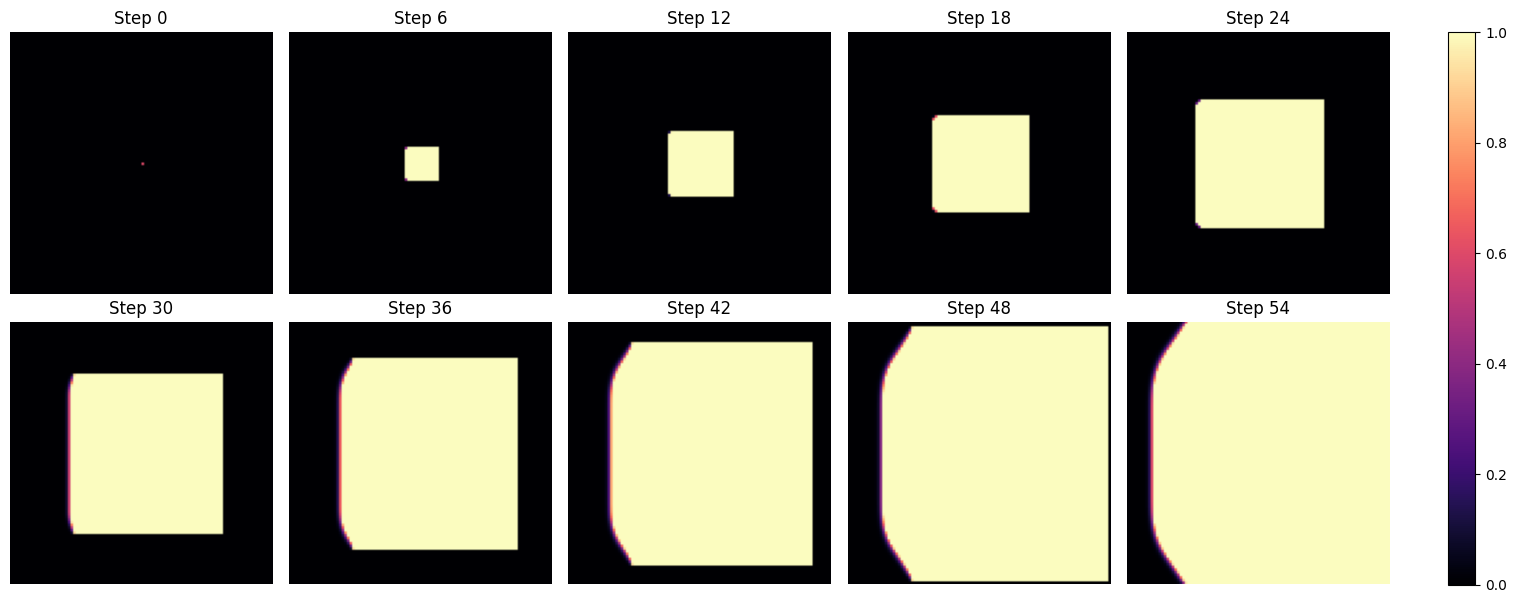

In [56]:
size = 100


# Vent en 4 bandes verticales d'intensité croissante :
# j=0-24  → vent faible  (0.1) : quasi pas de propagation
# j=25-49 → vent modéré  (1.0) : propagation normale
# j=50-74 → vent fort    (10.0): propagation accélérée
# j=75-99 → vent violent (20.0): propagation très rapide

wind = np.hstack([
    0.1 * np.ones((size, 25)), 
    1.0 * np.ones((size, 25)), 
    10.0 * np.ones((size, 25)), 
    20.0 * np.ones((size, 25))  
])
heights = np.zeros((size, size))  # Terrain plat pour isoler l'effet du vent

plt.figure(figsize=(6, 5))
im_wind = plt.imshow(wind, cmap='Blues', origin='upper')
plt.scatter(50, 50, color='red', s=150, zorder=5, marker='*', label="Foyer (50, 50)")
plt.axvline(25, color='white', linestyle='--', linewidth=1)
plt.axvline(50, color='white', linestyle='--', linewidth=1)
plt.axvline(75, color='white', linestyle='--', linewidth=1)
plt.text(12, 5, "0.1",  color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(37, 5, "1.0",  color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(62, 5, "10.0", color='white', ha='center', fontsize=11, fontweight='bold')
plt.text(87, 5, "20.0", color='white', ha='center', fontsize=11, fontweight='bold')
plt.title("Distribution du vent")
plt.colorbar(im_wind, label="Intensité du vent")
plt.legend(loc="lower right")
plt.axis('off')
plt.tight_layout()
plt.show()

CA = CellularAutomaton(size, size, wind, heights, height_update)


CA.initialize_ignition([(50, 50)], [0.6])

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()
plot_idx = 0


for step in range(60): 
    if step % 6 == 0 and plot_idx < 10: 
        current_state = CA.get_state()
        im = axes[plot_idx].imshow(current_state, vmin=0, vmax=1, cmap='magma')
        axes[plot_idx].set_title(f"Step {step}")
        axes[plot_idx].axis('off')
        plot_idx += 1

    CA.evolve()

plt.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, pad=0.04)
plt.show()

Ici,  on a pris un vent qui est de plus en plus fort à mesure qu'on va vers la droite. Intuitivement, le feu devrait se propager plus rapidement vers la droite que vers la gauche et c'est bien ce qu'on observe en pratique.

Maintenant, on va regarder ce qu'il se passe ne mettant différents types de vent


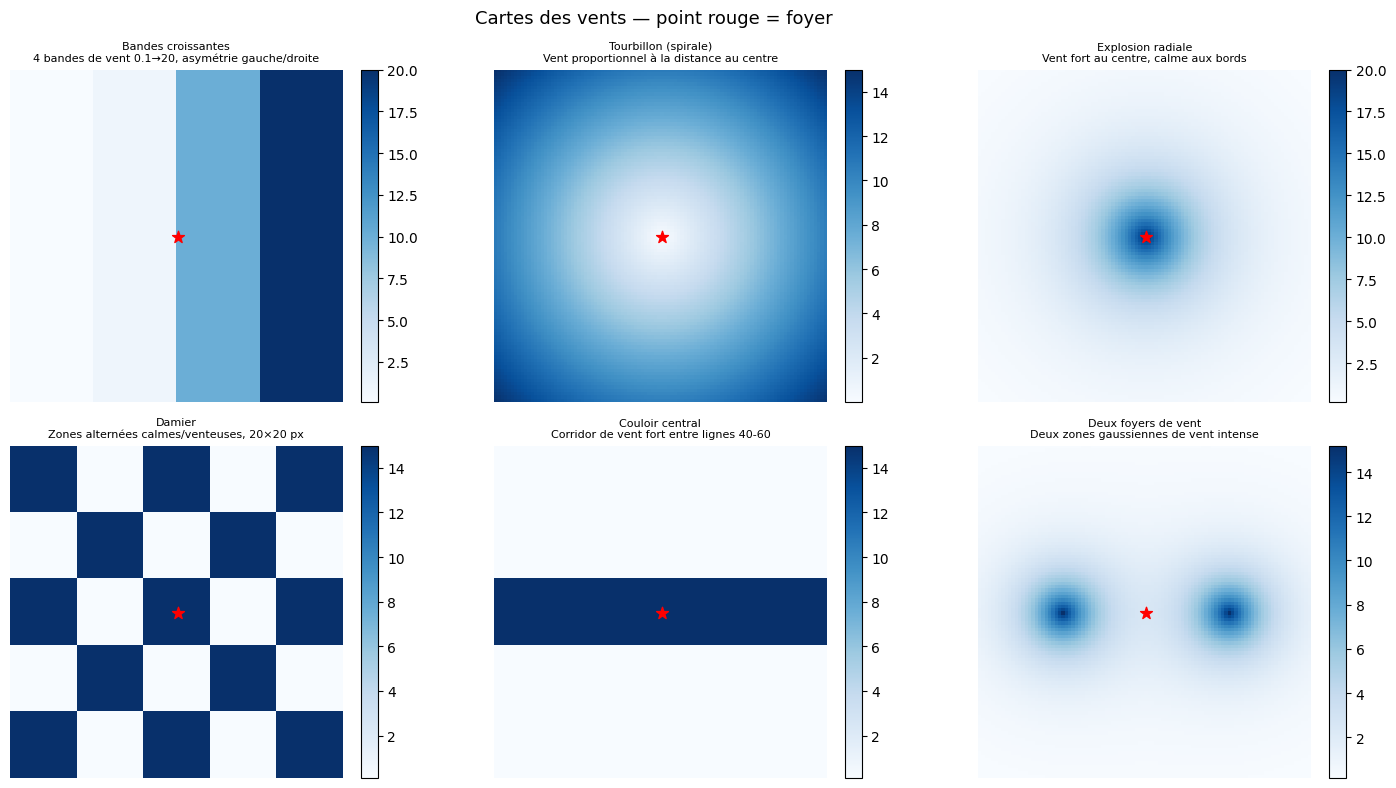

C:\Users\leala\AppData\Local\Temp\ipykernel_21280\1917282656.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


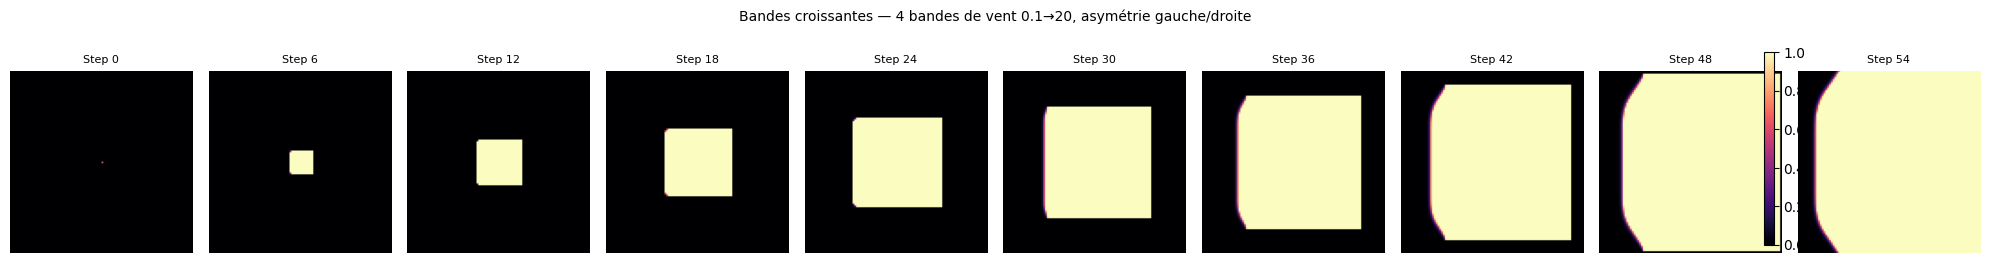

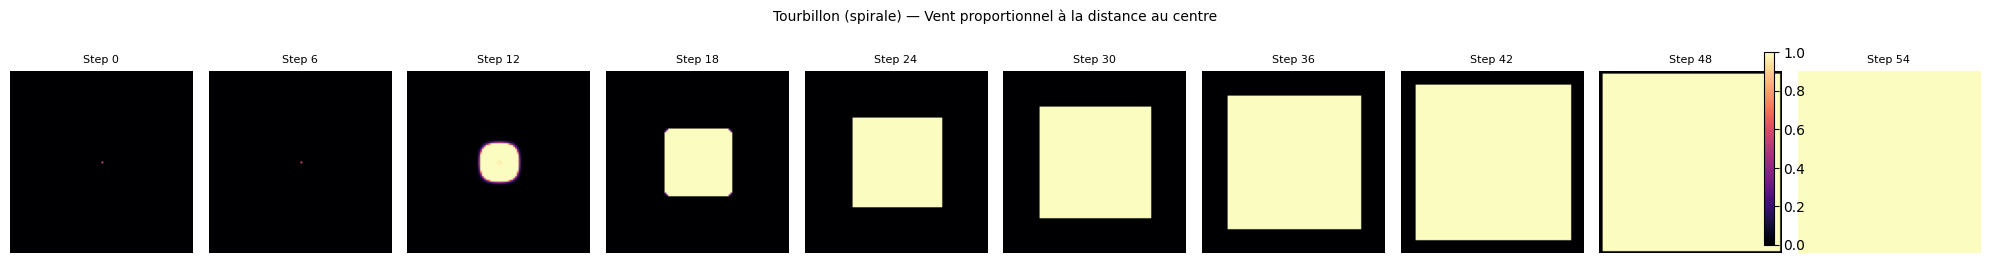

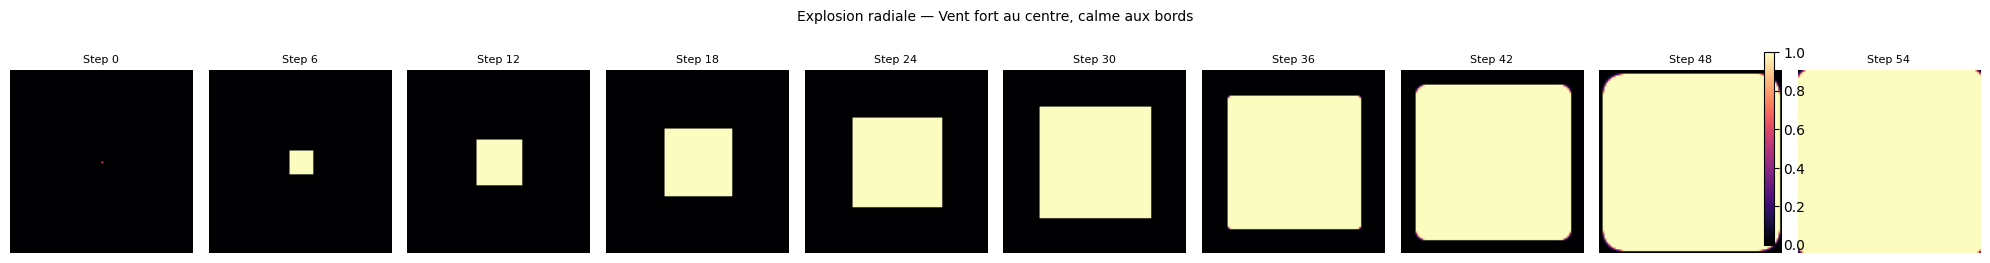

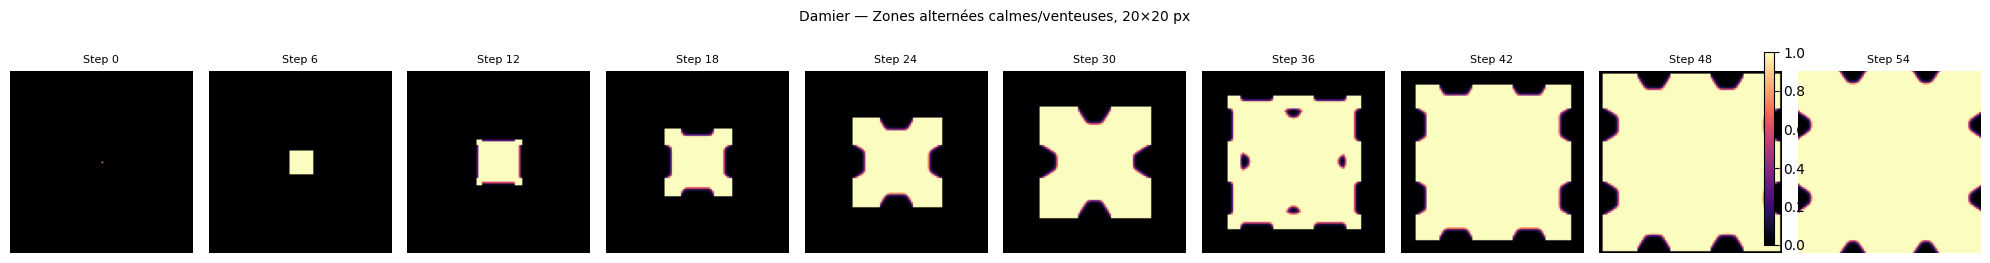

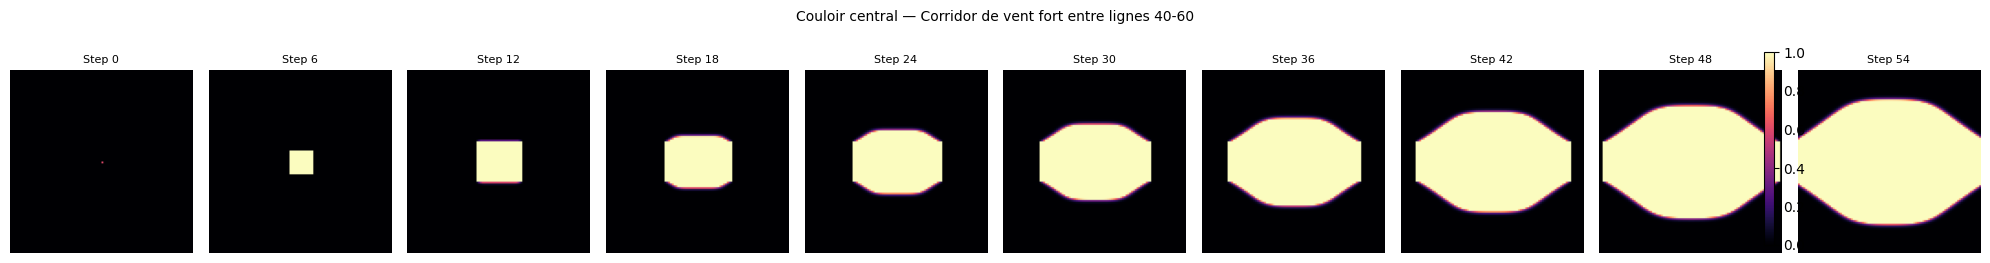

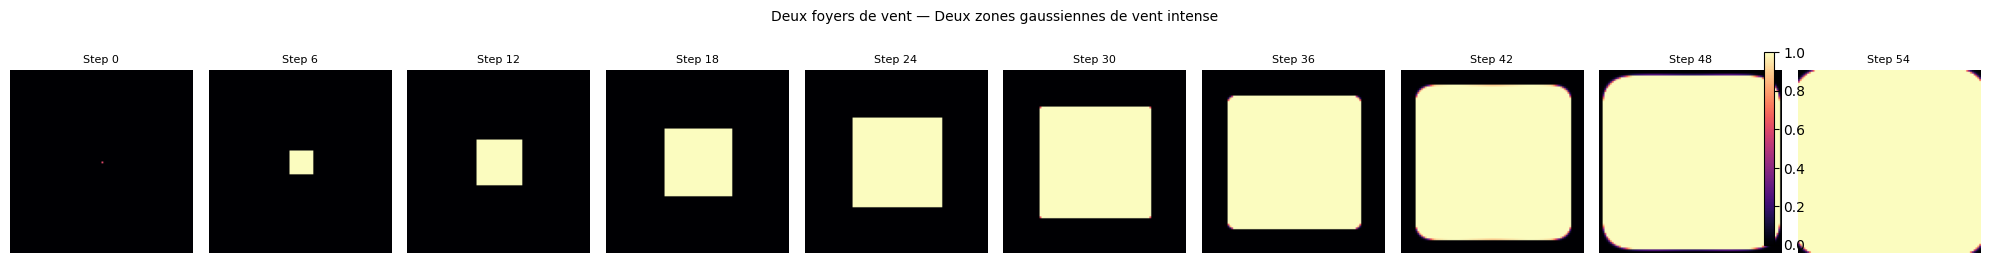

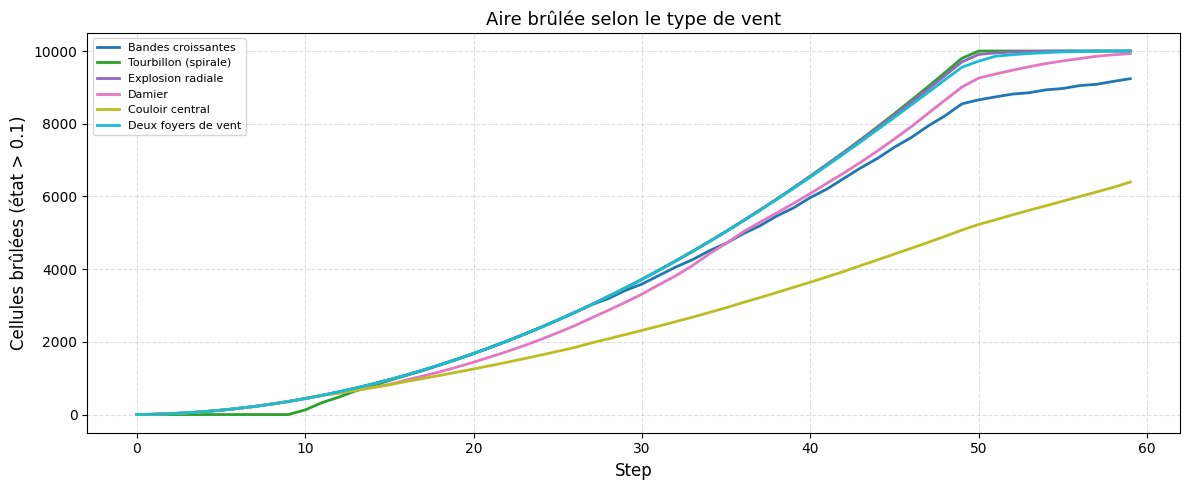

In [57]:
size = 100
x_grid, y_grid = np.meshgrid(np.linspace(-1, 1, size), np.linspace(-1, 1, size))
heights = np.zeros((size, size))

def make_wind(name):
    if name == "Bandes croissantes":
        return np.hstack([0.1*np.ones((size,25)), 1.0*np.ones((size,25)),
                          10.0*np.ones((size,25)), 20.0*np.ones((size,25))])

    elif name == "Tourbillon (spirale)":
        # Vent proportionnel à la distance au centre, sens horaire
        cx, cy = size//2, size//2
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        dist = np.sqrt((i_grid - cx)**2 + (j_grid - cy)**2) + 1e-5
        return (dist / dist.max()) * 15

    elif name == "Explosion radiale":
        # Vent maximal au centre, décroît vers les bords
        cx, cy = size//2, size//2
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        dist = np.sqrt((i_grid - cx)**2 + (j_grid - cy)**2)
        return np.exp(-dist / 15) * 20

    elif name == "Damier":
        # Alternance de zones calmes et venteuses
        wind = np.ones((size, size))
        for i in range(size):
            for j in range(size):
                wind[i, j] = 15.0 if ((i // 20) + (j // 20)) % 2 == 0 else 0.1
        return wind

    elif name == "Couloir central":
        # Vent fort uniquement au centre (corridor)
        wind = 0.1 * np.ones((size, size))
        wind[40:60, :] = 15.0
        return wind

    elif name == "Deux foyers de vent":
        # Deux zones de vent fort symétriques
        wind = 0.1 * np.ones((size, size))
        cx1, cx2 = size//4, 3*size//4
        i_grid, j_grid = np.meshgrid(np.arange(size), np.arange(size), indexing='ij')
        for cx in [cx1, cx2]:
            dist = np.sqrt((i_grid - size//2)**2 + (j_grid - cx)**2)
            wind += np.exp(-dist / 10) * 15
        return np.clip(wind, 0, 20)

wind_configs = {
    "Bandes croissantes":  {"wind": make_wind("Bandes croissantes"),  "desc": "4 bandes de vent 0.1→20, asymétrie gauche/droite"},
    "Tourbillon (spirale)":{"wind": make_wind("Tourbillon (spirale)"),"desc": "Vent proportionnel à la distance au centre"},
    "Explosion radiale":   {"wind": make_wind("Explosion radiale"),   "desc": "Vent fort au centre, calme aux bords"},
    "Damier":              {"wind": make_wind("Damier"),              "desc": "Zones alternées calmes/venteuses, 20×20 px"},
    "Couloir central":     {"wind": make_wind("Couloir central"),     "desc": "Corridor de vent fort entre lignes 40-60"},
    "Deux foyers de vent": {"wind": make_wind("Deux foyers de vent"), "desc": "Deux zones gaussiennes de vent intense"},
}

n_steps       = 10
step_interval = 6
total_steps   = n_steps * step_interval

# ── Cartes des vents ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (name, cfg) in zip(axes.flatten(), wind_configs.items()):
    im = ax.imshow(cfg["wind"], cmap='Blues', origin='upper')
    ax.scatter(50, 50, color='red', s=80, zorder=5, marker='*')
    ax.set_title(f"{name}\n{cfg['desc']}", fontsize=8)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Cartes des vents — point rouge = foyer", fontsize=13)
plt.tight_layout()
plt.show()

# ── Simulation + aire brûlée ─────────────────────────────────────────────
burned_histories = {}

for name, cfg in wind_configs.items():
    wind = cfg["wind"]
    CA = CellularAutomaton(size, size, wind, heights, height_update)
    CA.initialize_ignition([(50, 50)], [0.6])

    burned    = []
    snapshots = []
    plot_idx  = 0

    for step in range(total_steps):
        burned.append(np.sum(CA.get_state() > 0.1))
        if step % step_interval == 0 and plot_idx < n_steps:
            snapshots.append((step, CA.get_state().copy()))
            plot_idx += 1
        CA.evolve()

    burned_histories[name] = burned

    fig, axes = plt.subplots(1, n_steps, figsize=(20, 2.5))
    for ax, (step, state) in zip(axes, snapshots):
        im = ax.imshow(state, vmin=0, vmax=1, cmap='magma')
        ax.set_title(f"Step {step}", fontsize=8)
        ax.axis('off')
    fig.suptitle(f"{name} — {cfg['desc']}", fontsize=10, y=1.05)
    plt.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

# ── Aire brûlée ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.tab10(np.linspace(0, 1, len(wind_configs)))
for (name, burned), color in zip(burned_histories.items(), colors):
    ax.plot(burned, linewidth=2, color=color, label=name)
ax.set_xlabel("Step", fontsize=12)
ax.set_ylabel("Cellules brûlées (état > 0.1)", fontsize=12)
ax.set_title("Aire brûlée selon le type de vent", fontsize=13)
ax.legend(fontsize=8, loc="upper left")
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()